# Model Playstyle & Strategic Adaptation Analysis

Analyzes how AI models adapt their Diplomacy playstyle across a 3-game experiment with cross-game memory (v2).

Key questions:
- Do models learn and improve across games?
- How do aggression levels change with experience?
- Do models that were betrayed adapt their diplomatic behavior?
- What distinct personality profiles emerge?

## 1. Data Loading

In [1]:
import os
import json
import csv
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Paths
V2_BASE = os.path.join("..", "results", "3game_experiment_v2")
V1_BASE = os.path.join("..", "results", "3game_experiment")

def clean_model_name(name):
    """Strip 'openrouter:' prefix from model names."""
    return name.split(":", 1)[-1] if ":" in name else name

def short_model_name(name):
    """Get a short display name from full model path."""
    cleaned = clean_model_name(name)
    # Return just the model part after the provider/
    return cleaned.split("/")[-1] if "/" in cleaned else cleaned

# Load experiment summaries
with open(os.path.join(V2_BASE, "experiment_summary.json"), "r") as f:
    v2_summary = json.load(f)

with open(os.path.join(V1_BASE, "experiment_summary.json"), "r") as f:
    v1_summary = json.load(f)

print(f"V2 Experiment: {v2_summary['experiment_name']} ({v2_summary['completed_games']} games)")
print(f"V1 Experiment: {v1_summary['experiment_name']} ({v1_summary['completed_games']} games)")

V2 Experiment: k8s_3game_memory_v2 (3 games)
V1 Experiment: k8s_3game_memory (3 games)


In [2]:
# Build model performance dataframe for v2
rows = []
for game_key in ["game1", "game2", "game3"]:
    game_data = v2_summary["results"][game_key]
    power_model_map = game_data["power_model_map"]
    supply_centers = game_data["supply_centers"]
    game_num = int(game_key.replace("game", ""))
    
    for power, model in power_model_map.items():
        sc_data = supply_centers[power]
        rows.append({
            "game": game_num,
            "model_full": clean_model_name(model),
            "model": short_model_name(model),
            "power": power,
            "sc_count": sc_data["count"],
            "eliminated": sc_data["eliminated"],
            "experiment": "v2"
        })

# Build same for v1
for game_key in ["game1", "game2", "game3"]:
    game_data = v1_summary["results"][game_key]
    power_model_map = game_data["power_model_map"]
    supply_centers = game_data["supply_centers"]
    game_num = int(game_key.replace("game", ""))
    
    for power, model in power_model_map.items():
        sc_data = supply_centers[power]
        rows.append({
            "game": game_num,
            "model_full": clean_model_name(model),
            "model": short_model_name(model),
            "power": power,
            "sc_count": sc_data["count"],
            "eliminated": sc_data["eliminated"],
            "experiment": "v1"
        })

df_performance = pd.DataFrame(rows)
print("Performance DataFrame:")
print(df_performance[df_performance["experiment"] == "v2"].to_string(index=False))

Performance DataFrame:
 game                   model_full                 model   power  sc_count  eliminated experiment
    1           x-ai/grok-4.1-fast         grok-4.1-fast AUSTRIA         0        True         v2
    1        google/gemma-4-31b-it        gemma-4-31b-it ENGLAND         7       False         v2
    1 google/gemini-2.5-flash-lite gemini-2.5-flash-lite  FRANCE         2       False         v2
    1             qwen/qwen3.5-27b           qwen3.5-27b GERMANY         6       False         v2
    1            qwen/qwen3.6-plus          qwen3.6-plus   ITALY        10       False         v2
    1          openai/gpt-oss-120b          gpt-oss-120b  RUSSIA         3       False         v2
    1   anthropic/claude-haiku-4.5      claude-haiku-4.5  TURKEY         6       False         v2
    2        google/gemma-4-31b-it        gemma-4-31b-it AUSTRIA         7       False         v2
    2 google/gemini-2.5-flash-lite gemini-2.5-flash-lite ENGLAND         1       False         

In [3]:
# Load LLM responses for v2 games
llm_dfs = {}
for game_num in [1, 2, 3]:
    csv_path = os.path.join(V2_BASE, f"game{game_num}", "llm_responses.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df["game"] = game_num
        df["model_clean"] = df["model"].apply(clean_model_name)
        df["model_short"] = df["model"].apply(lambda x: short_model_name(x))
        llm_dfs[game_num] = df
        print(f"Game {game_num}: {len(df)} responses, types: {df['response_type'].value_counts().to_dict()}")
    else:
        print(f"Game {game_num}: llm_responses.csv not found")

# Combine all games
df_all = pd.concat(llm_dfs.values(), ignore_index=True)
print(f"\nTotal responses: {len(df_all)}")

Game 1: 770 responses, types: {'negotiation_message': 260, 'order_generation': 185, 'negotiation_diary': 130, 'phase_result_diary': 130, 'diary_consolidation': 58, 'initial_state_setup': 7}
Game 2: 815 responses, types: {'negotiation_message': 280, 'order_generation': 185, 'negotiation_diary': 140, 'phase_result_diary': 140, 'diary_consolidation': 63, 'initial_state_setup': 7}


Game 3: 740 responses, types: {'negotiation_message': 248, 'order_generation': 182, 'negotiation_diary': 124, 'phase_result_diary': 124, 'diary_consolidation': 55, 'initial_state_setup': 7}

Total responses: 2325


## 2. Model Performance Trajectory

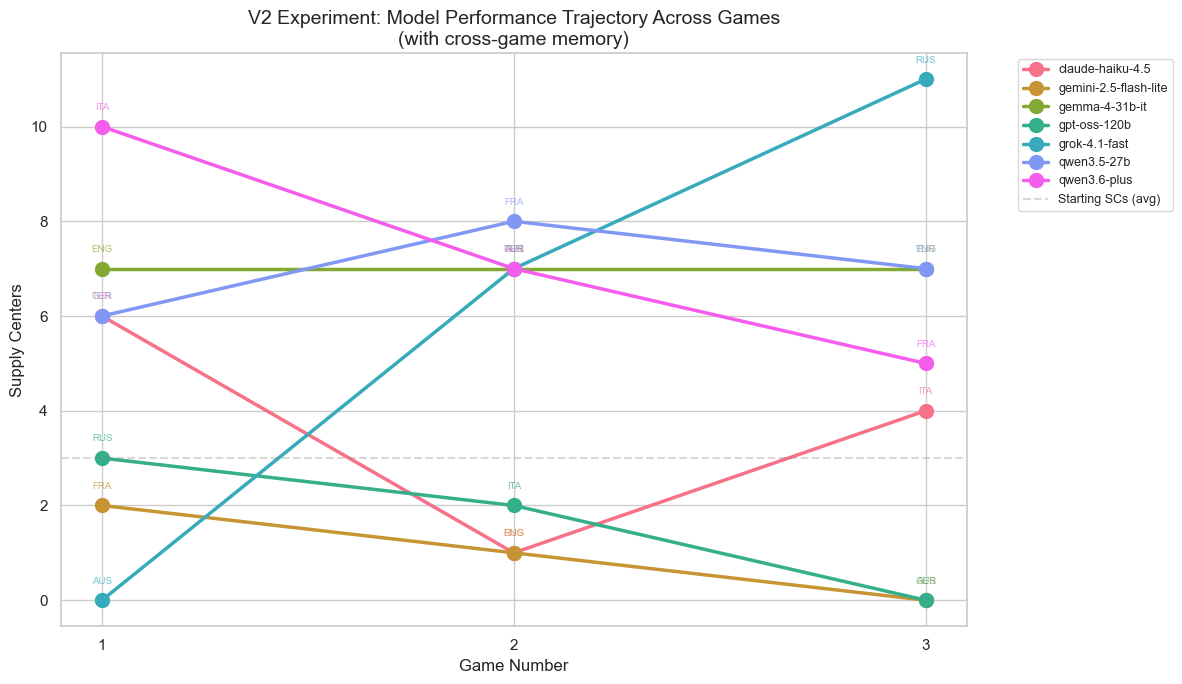

In [4]:
# V2 performance trajectory: SC count per model across games
df_v2 = df_performance[df_performance["experiment"] == "v2"].copy()

fig, ax = plt.subplots(figsize=(12, 7))

models = df_v2["model"].unique()
colors = sns.color_palette("husl", len(models))

for i, model in enumerate(sorted(models)):
    model_data = df_v2[df_v2["model"] == model].sort_values("game")
    ax.plot(model_data["game"], model_data["sc_count"], 
            marker='o', linewidth=2.5, markersize=10,
            label=model, color=colors[i])
    
    # Annotate with power played
    for _, row in model_data.iterrows():
        offset = 0.3 if row["sc_count"] > 5 else -0.5
        ax.annotate(row["power"][:3], 
                   (row["game"], row["sc_count"]),
                   textcoords="offset points", xytext=(0, 12),
                   fontsize=7, ha='center', alpha=0.7,
                   color=colors[i])

ax.set_xlabel("Game Number", fontsize=12)
ax.set_ylabel("Supply Centers", fontsize=12)
ax.set_title("V2 Experiment: Model Performance Trajectory Across Games\n(with cross-game memory)", fontsize=14)
ax.set_xticks([1, 2, 3])
ax.axhline(y=3, color='gray', linestyle='--', alpha=0.3, label='Starting SCs (avg)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

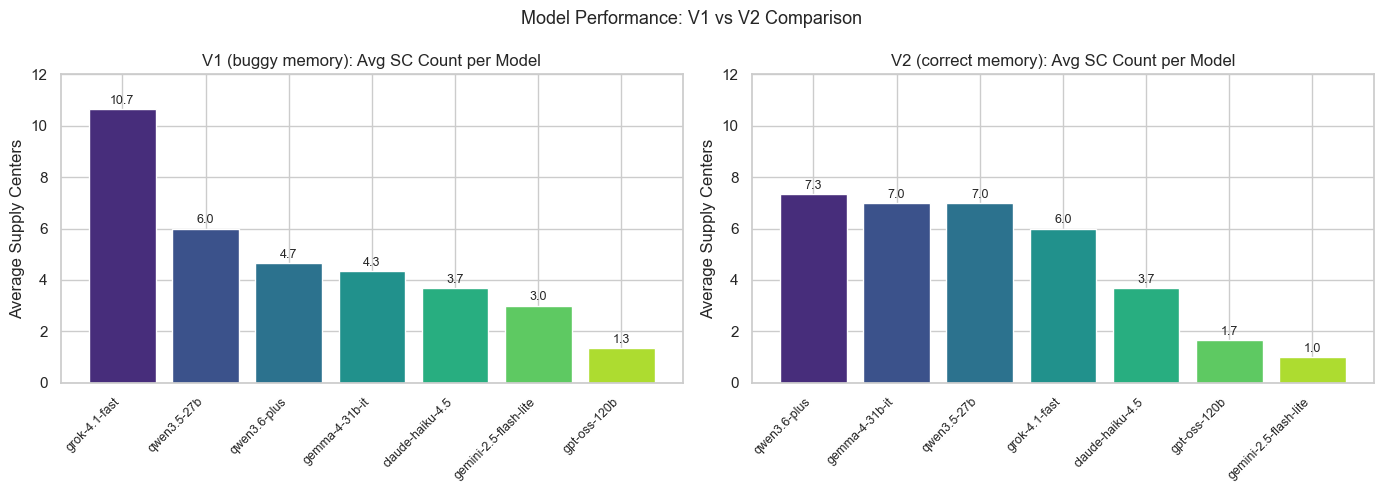

In [5]:
# V1 vs V2 comparison: average SC count per model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (exp, title) in enumerate([("v1", "V1 (buggy memory)"), ("v2", "V2 (correct memory)")]):
    df_exp = df_performance[df_performance["experiment"] == exp]
    avg_sc = df_exp.groupby("model")["sc_count"].mean().sort_values(ascending=False)
    
    bars = axes[idx].bar(range(len(avg_sc)), avg_sc.values, color=sns.color_palette("viridis", len(avg_sc)))
    axes[idx].set_xticks(range(len(avg_sc)))
    axes[idx].set_xticklabels(avg_sc.index, rotation=45, ha='right', fontsize=9)
    axes[idx].set_ylabel("Average Supply Centers")
    axes[idx].set_title(f"{title}: Avg SC Count per Model")
    axes[idx].set_ylim(0, 12)
    
    # Add value labels
    for bar, val in zip(bars, avg_sc.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                      f"{val:.1f}", ha='center', fontsize=9)

plt.suptitle("Model Performance: V1 vs V2 Comparison", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Aggression Analysis

In [6]:
def parse_orders(raw_response):
    """Extract orders from order_generation responses."""
    orders = []
    if not isinstance(raw_response, str):
        return orders
    
    # Try to find JSON with orders
    try:
        # Look for JSON block after PARSABLE OUTPUT:
        json_match = re.search(r'PARSABLE OUTPUT:\s*({.*?})', raw_response, re.DOTALL)
        if json_match:
            data = json.loads(json_match.group(1))
            if "orders" in data:
                return data["orders"]
    except (json.JSONDecodeError, AttributeError):
        pass
    
    # Try to find any JSON with orders key
    try:
        json_match = re.search(r'{[^{}]*"orders"\s*:\s*\[([^\]]+)\][^{}]*}', raw_response, re.DOTALL)
        if json_match:
            data = json.loads(json_match.group(0))
            if "orders" in data:
                return data["orders"]
    except (json.JSONDecodeError, AttributeError):
        pass
    
    # Fallback: look for order patterns line by line
    # Orders look like: A WAR - UKR, F LON S A YOR - NWY, A MUN H
    order_pattern = re.compile(r'[AF]\s+[A-Z]{3}(?:/[A-Z]{2,3})?\s+(?:[-HS]|C\s|R\s)')
    for line in raw_response.split('\n'):
        line = line.strip().strip('"').strip(',')
        if order_pattern.match(line):
            orders.append(line)
    
    return orders

def classify_order(order):
    """Classify an order as aggressive, supportive, or passive."""
    order_upper = order.upper()
    if ' H' in order_upper and (order_upper.endswith(' H') or order_upper.endswith(' HOLD')):
        return 'hold'
    elif ' S ' in order_upper or 'SUPPORT' in order_upper:
        # Support can be offensive (supporting an attack) or defensive (supporting a hold)
        if ' - ' in order_upper.split(' S ', 1)[-1]:
            return 'support_attack'
        else:
            return 'support_defend'
    elif ' C ' in order_upper or 'CONVOY' in order_upper:
        return 'convoy'
    elif ' - ' in order_upper:
        return 'move'
    elif ' R ' in order_upper:
        return 'retreat'
    else:
        return 'other'

# Parse all orders from order_generation responses
df_orders = df_all[df_all["response_type"] == "order_generation"].copy()

order_records = []
for _, row in df_orders.iterrows():
    orders = parse_orders(row["raw_response"])
    for order in orders:
        order_type = classify_order(order)
        order_records.append({
            "game": row["game"],
            "model": row["model_short"],
            "model_full": row["model_clean"],
            "power": row["power"],
            "phase": row["phase"],
            "order": order,
            "order_type": order_type
        })

df_order_types = pd.DataFrame(order_records)
print(f"Total parsed orders: {len(df_order_types)}")
print(f"\nOrder type distribution:")
print(df_order_types["order_type"].value_counts())

Total parsed orders: 2153

Order type distribution:
order_type
move              1029
hold               450
support_attack     272
retreat            183
other              123
support_defend      91
convoy               5
Name: count, dtype: int64


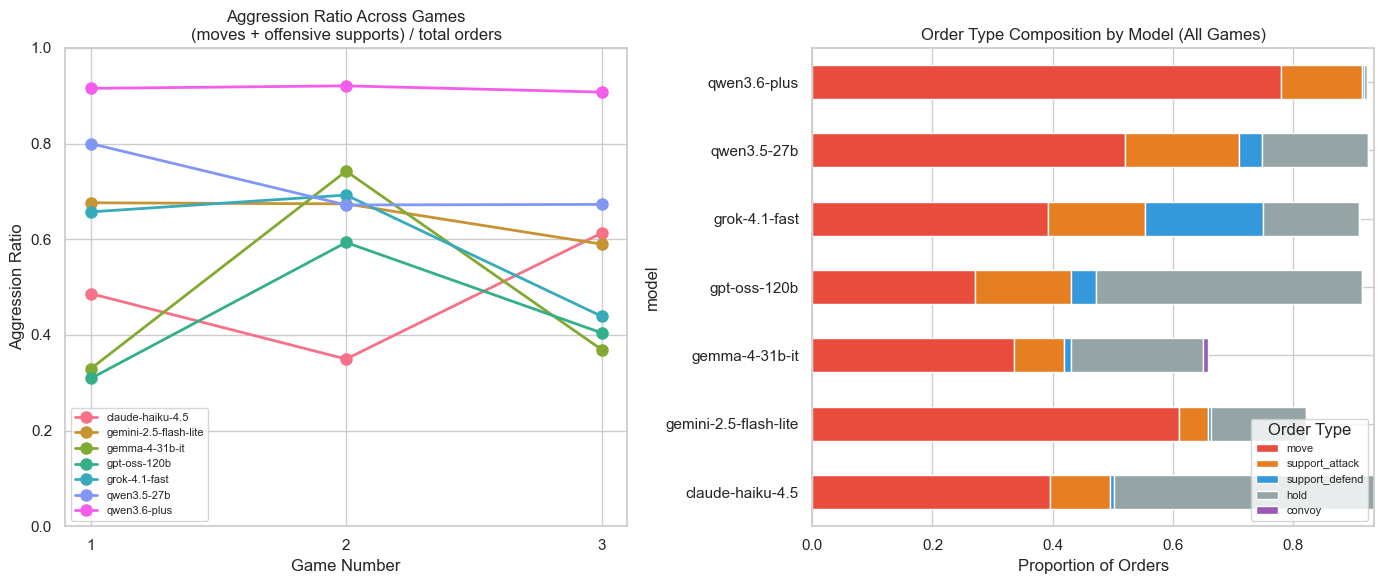

In [7]:
# Aggression ratio per model per game
# Aggressive = moves + support_attack + convoy
# Passive = holds + support_defend

def compute_aggression(group):
    total = len(group)
    if total == 0:
        return pd.Series({"aggression_ratio": 0, "total_orders": 0})
    aggressive = group[group["order_type"].isin(["move", "support_attack", "convoy"])].shape[0]
    return pd.Series({
        "aggression_ratio": aggressive / total,
        "total_orders": total
    })

aggression_by_model_game = df_order_types.groupby(["model", "game"]).apply(compute_aggression).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: aggression ratio per model across games
for i, model in enumerate(sorted(aggression_by_model_game["model"].unique())):
    model_data = aggression_by_model_game[aggression_by_model_game["model"] == model].sort_values("game")
    axes[0].plot(model_data["game"], model_data["aggression_ratio"],
                marker='o', linewidth=2, markersize=8,
                label=model, color=colors[i])

axes[0].set_xlabel("Game Number")
axes[0].set_ylabel("Aggression Ratio")
axes[0].set_title("Aggression Ratio Across Games\n(moves + offensive supports) / total orders")
axes[0].set_xticks([1, 2, 3])
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)

# Right: order type breakdown by model (all games combined)
order_counts = df_order_types.groupby(["model", "order_type"]).size().unstack(fill_value=0)
order_pcts = order_counts.div(order_counts.sum(axis=1), axis=0)

order_pcts[["move", "support_attack", "support_defend", "hold", "convoy"]].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=["#e74c3c", "#e67e22", "#3498db", "#95a5a6", "#9b59b6"]
)
axes[1].set_xlabel("Proportion of Orders")
axes[1].set_title("Order Type Composition by Model (All Games)")
axes[1].legend(title="Order Type", fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

In [8]:
# Do models that were eliminated play differently in subsequent games?
# Check which models were eliminated and their aggression change

elimination_info = []
for game_key in ["game1", "game2", "game3"]:
    game_data = v2_summary["results"][game_key]
    game_num = int(game_key.replace("game", ""))
    for power, sc_data in game_data["supply_centers"].items():
        model = short_model_name(game_data["power_model_map"][power])
        if sc_data["eliminated"]:
            elimination_info.append({"model": model, "eliminated_in_game": game_num})

print("Models eliminated in v2:")
for info in elimination_info:
    print(f"  {info['model']} - eliminated in Game {info['eliminated_in_game']}")

# Compare aggression before/after elimination experience
print("\nAggression ratio changes (models that experienced elimination):")
for info in elimination_info:
    model = info["model"]
    game_elim = info["eliminated_in_game"]
    model_agg = aggression_by_model_game[aggression_by_model_game["model"] == model]
    if not model_agg.empty:
        print(f"  {model}:")
        for _, row in model_agg.iterrows():
            marker = " <-- eliminated" if row["game"] == game_elim else ""
            print(f"    Game {int(row['game'])}: aggression={row['aggression_ratio']:.3f}{marker}")

Models eliminated in v2:
  grok-4.1-fast - eliminated in Game 1
  gemini-2.5-flash-lite - eliminated in Game 3
  gpt-oss-120b - eliminated in Game 3

Aggression ratio changes (models that experienced elimination):
  grok-4.1-fast:
    Game 1: aggression=0.657 <-- eliminated
    Game 2: aggression=0.692
    Game 3: aggression=0.439
  gemini-2.5-flash-lite:
    Game 1: aggression=0.676
    Game 2: aggression=0.674
    Game 3: aggression=0.590 <-- eliminated
  gpt-oss-120b:
    Game 1: aggression=0.309
    Game 2: aggression=0.593
    Game 3: aggression=0.404 <-- eliminated


## 4. Diplomatic Activity

In [9]:
# Count messages sent per model per game
df_messages = df_all[df_all["response_type"] == "negotiation_message"].copy()

def count_messages(raw_response):
    """Count individual messages in a negotiation_message response."""
    if not isinstance(raw_response, str):
        return 0
    try:
        messages = json.loads(raw_response)
        if isinstance(messages, list):
            return len(messages)
    except (json.JSONDecodeError, TypeError):
        pass
    # Fallback: count message_type occurrences
    return raw_response.count('"message_type"')

def count_private_messages(raw_response):
    """Count private messages specifically."""
    if not isinstance(raw_response, str):
        return 0
    try:
        messages = json.loads(raw_response)
        if isinstance(messages, list):
            return sum(1 for m in messages if m.get("message_type") == "private")
    except (json.JSONDecodeError, TypeError):
        pass
    return raw_response.count('"private"')

df_messages["msg_count"] = df_messages["raw_response"].apply(count_messages)
df_messages["private_count"] = df_messages["raw_response"].apply(count_private_messages)

msg_summary = df_messages.groupby(["model_short", "game"]).agg(
    total_messages=("msg_count", "sum"),
    private_messages=("private_count", "sum"),
    negotiation_rounds=("msg_count", "count")
).reset_index()

print("Message counts by model and game:")
print(msg_summary.pivot_table(index="model_short", columns="game", values="total_messages", aggfunc="sum").to_string())

Message counts by model and game:
game                     1    2    3
model_short                         
claude-haiku-4.5       129  164  150
gemini-2.5-flash-lite  181  235   71
gemma-4-31b-it         106  133  117
gpt-oss-120b           149  166  105
grok-4.1-fast           80  166  183
qwen3.5-27b            197  163  126
qwen3.6-plus           146  173  158


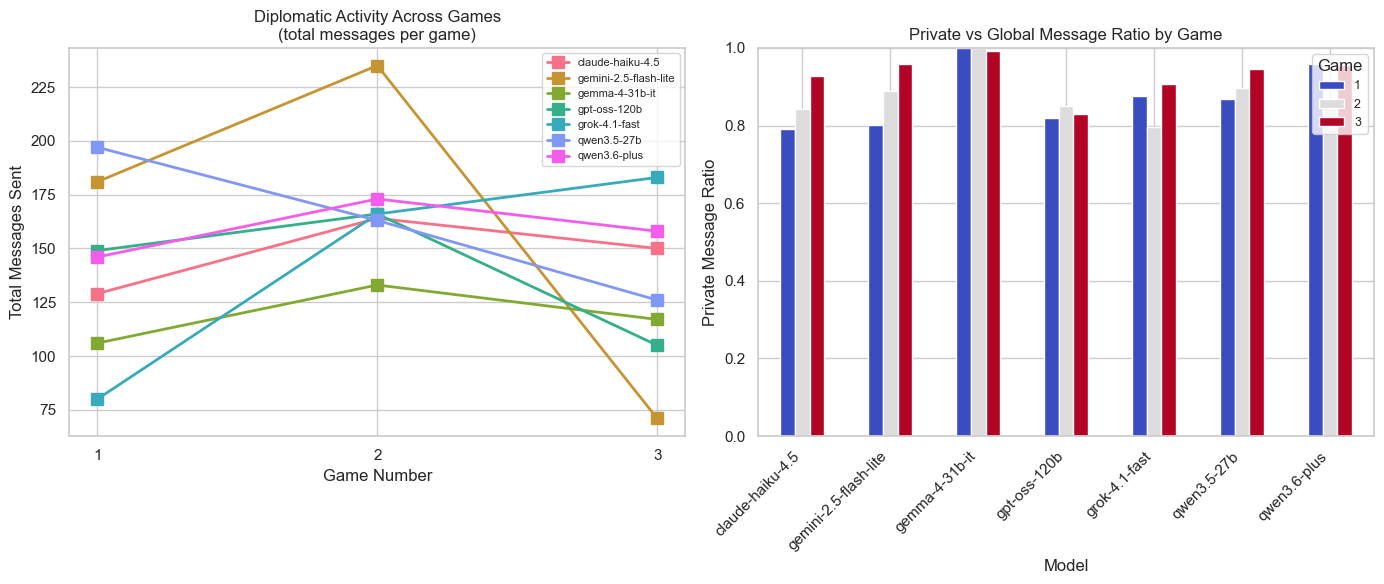

In [10]:
# Visualization: diplomatic activity
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: total messages per model across games
for i, model in enumerate(sorted(msg_summary["model_short"].unique())):
    model_data = msg_summary[msg_summary["model_short"] == model].sort_values("game")
    axes[0].plot(model_data["game"], model_data["total_messages"],
                marker='s', linewidth=2, markersize=8,
                label=model, color=colors[i])

axes[0].set_xlabel("Game Number")
axes[0].set_ylabel("Total Messages Sent")
axes[0].set_title("Diplomatic Activity Across Games\n(total messages per game)")
axes[0].set_xticks([1, 2, 3])
axes[0].legend(fontsize=8)

# Right: private vs global message ratio
msg_summary["private_ratio"] = msg_summary["private_messages"] / msg_summary["total_messages"].clip(lower=1)
pivot_private = msg_summary.pivot_table(index="model_short", columns="game", values="private_ratio")
pivot_private.plot(kind="bar", ax=axes[1], colormap="coolwarm")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Private Message Ratio")
axes[1].set_title("Private vs Global Message Ratio by Game")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].legend(title="Game", fontsize=9)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 5. Relationship Patterns

In [11]:
# Extract relationship and trust data from negotiation_diary responses
df_diary = df_all[df_all["response_type"] == "negotiation_diary"].copy()

def extract_relationships(raw_response):
    """Extract updated_relationships and trust_scores from diary JSON."""
    if not isinstance(raw_response, str):
        return None, None
    
    # Clean markdown code blocks if present
    text = raw_response.strip()
    if text.startswith("```"):
        text = text.split("\n", 1)[-1]
        if text.endswith("```"):
            text = text[:-3]
    
    try:
        data = json.loads(text)
        relationships = data.get("updated_relationships", None)
        trust_scores = data.get("trust_scores", None)
        return relationships, trust_scores
    except (json.JSONDecodeError, TypeError):
        # Try to find JSON within the text
        try:
            match = re.search(r'\{[\s\S]*"updated_relationships"[\s\S]*\}', text)
            if match:
                data = json.loads(match.group(0))
                return data.get("updated_relationships"), data.get("trust_scores")
        except (json.JSONDecodeError, TypeError):
            pass
    return None, None

trust_records = []
relationship_records = []

for _, row in df_diary.iterrows():
    relationships, trust_scores = extract_relationships(row["raw_response"])
    
    if trust_scores:
        for target_power, score in trust_scores.items():
            if target_power.upper() != row["power"]:
                try:
                    trust_records.append({
                        "game": row["game"],
                        "model": row["model_short"],
                        "power": row["power"],
                        "target_power": target_power.upper(),
                        "trust_score": float(score),
                        "phase": row["phase"]
                    })
                except (ValueError, TypeError):
                    pass
    
    if relationships:
        for target_power, rel_status in relationships.items():
            if target_power.upper() != row["power"]:
                relationship_records.append({
                    "game": row["game"],
                    "model": row["model_short"],
                    "power": row["power"],
                    "target_power": target_power.upper(),
                    "relationship": str(rel_status).lower(),
                    "phase": row["phase"]
                })

df_trust = pd.DataFrame(trust_records)
df_relationships = pd.DataFrame(relationship_records)

print(f"Trust records: {len(df_trust)}")
print(f"Relationship records: {len(df_relationships)}")
if not df_trust.empty:
    print(f"\nAverage trust by model (across all games):")
    print(df_trust.groupby("model")["trust_score"].mean().sort_values(ascending=False))

Trust records: 2252
Relationship records: 2253

Average trust by model (across all games):
model
grok-4.1-fast            0.531333
gpt-oss-120b             0.517901
gemma-4-31b-it           0.433611
qwen3.6-plus             0.417778
claude-haiku-4.5         0.413659
qwen3.5-27b              0.282566
gemini-2.5-flash-lite    0.240854
Name: trust_score, dtype: float64


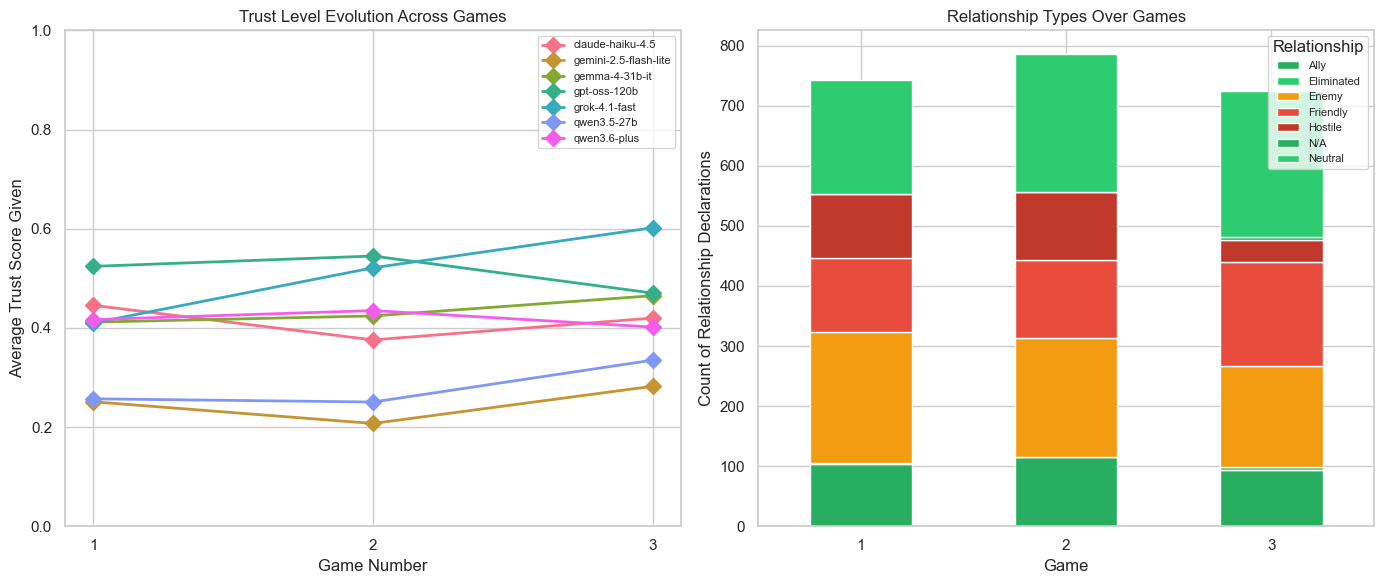

In [12]:
# Trust evolution across games
if not df_trust.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: average trust given by each model per game
    avg_trust_game = df_trust.groupby(["model", "game"])["trust_score"].mean().reset_index()
    
    for i, model in enumerate(sorted(avg_trust_game["model"].unique())):
        model_data = avg_trust_game[avg_trust_game["model"] == model].sort_values("game")
        axes[0].plot(model_data["game"], model_data["trust_score"],
                    marker='D', linewidth=2, markersize=8,
                    label=model, color=colors[i])
    
    axes[0].set_xlabel("Game Number")
    axes[0].set_ylabel("Average Trust Score Given")
    axes[0].set_title("Trust Level Evolution Across Games")
    axes[0].set_xticks([1, 2, 3])
    axes[0].set_ylim(0, 1)
    axes[0].legend(fontsize=8)
    
    # Right: relationship type distribution
    if not df_relationships.empty:
        # Normalize relationship labels
        rel_mapping = {
            'ally': 'Ally', 'allied': 'Ally', 'alliance': 'Ally',
            'friendly': 'Friendly', 'friend': 'Friendly',
            'neutral': 'Neutral', 'unknown': 'Neutral',
            'hostile': 'Hostile', 'enemy': 'Enemy', 'adversary': 'Enemy',
            'war': 'Enemy', 'rival': 'Hostile', 'unfriendly': 'Hostile'
        }
        df_relationships["rel_normalized"] = df_relationships["relationship"].map(
            lambda x: rel_mapping.get(x.strip(), x.strip().title())
        )
        
        rel_counts = df_relationships.groupby(["game", "rel_normalized"]).size().unstack(fill_value=0)
        rel_counts.plot(kind="bar", stacked=True, ax=axes[1],
                       color=["#27ae60", "#2ecc71", "#f39c12", "#e74c3c", "#c0392b"])
        axes[1].set_xlabel("Game")
        axes[1].set_ylabel("Count of Relationship Declarations")
        axes[1].set_title("Relationship Types Over Games")
        axes[1].legend(title="Relationship", fontsize=8)
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.show()
else:
    print("No trust data available to plot.")

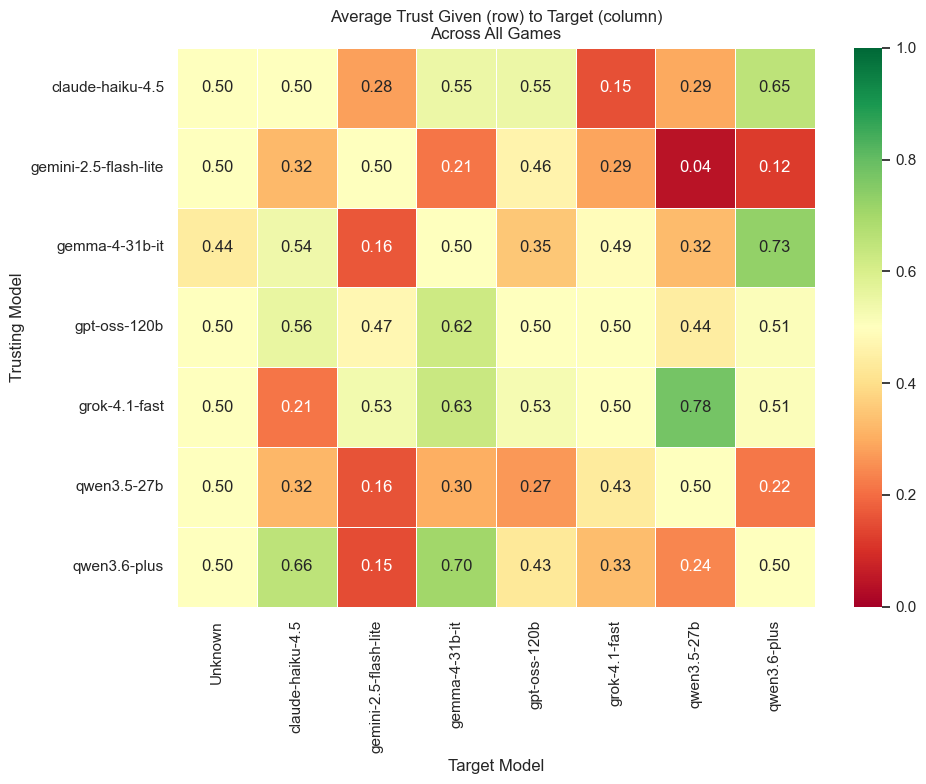

In [13]:
# Heatmap: average trust between models (who trusts whom) across all games
if not df_trust.empty:
    # Map powers to models for each game
    power_to_model = {}
    for game_key in ["game1", "game2", "game3"]:
        game_data = v2_summary["results"][game_key]
        game_num = int(game_key.replace("game", ""))
        for power, model in game_data["power_model_map"].items():
            power_to_model[(game_num, power)] = short_model_name(model)
    
    # Add target model column
    df_trust["target_model"] = df_trust.apply(
        lambda r: power_to_model.get((r["game"], r["target_power"]), "Unknown"), axis=1
    )
    
    # Create trust matrix
    trust_matrix = df_trust.groupby(["model", "target_model"])["trust_score"].mean().unstack(fill_value=0.5)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(trust_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
                vmin=0, vmax=1, center=0.5, ax=ax,
                linewidths=0.5)
    ax.set_title("Average Trust Given (row) to Target (column)\nAcross All Games", fontsize=12)
    ax.set_xlabel("Target Model")
    ax.set_ylabel("Trusting Model")
    plt.tight_layout()
    plt.show()

## 6. Model Personality Profiles

In [14]:
# Build personality profile dimensions for each model
models_list = sorted(df_performance[df_performance["experiment"] == "v2"]["model"].unique())

profiles = []
for model in models_list:
    profile = {"model": model}
    
    # 1. Aggressiveness (ratio of aggressive orders)
    model_orders = df_order_types[df_order_types["model"] == model]
    if len(model_orders) > 0:
        aggressive = model_orders[model_orders["order_type"].isin(["move", "support_attack", "convoy"])].shape[0]
        profile["aggressiveness"] = aggressive / len(model_orders)
    else:
        profile["aggressiveness"] = 0.5
    
    # 2. Diplomacy (normalized message volume)
    model_msgs = msg_summary[msg_summary["model_short"] == model]["total_messages"].sum()
    profile["diplomacy_raw"] = model_msgs
    
    # 3. Trust level (average trust given)
    if not df_trust.empty:
        model_trust = df_trust[df_trust["model"] == model]["trust_score"].mean()
        profile["trust_level"] = model_trust if not pd.isna(model_trust) else 0.5
    else:
        profile["trust_level"] = 0.5
    
    # 4. Survival rate (games not eliminated / total games)
    model_perf = df_performance[(df_performance["experiment"] == "v2") & (df_performance["model"] == model)]
    profile["survival_rate"] = 1 - model_perf["eliminated"].mean()
    
    # 5. Expansion rate (average SC count / starting position normalization)
    profile["avg_sc"] = model_perf["sc_count"].mean()
    
    # 6. Adaptability (variance in aggression across games — lower = more consistent)
    model_agg = aggression_by_model_game[aggression_by_model_game["model"] == model]
    if len(model_agg) > 1:
        profile["consistency"] = 1 - model_agg["aggression_ratio"].std()
    else:
        profile["consistency"] = 0.5
    
    profiles.append(profile)

df_profiles = pd.DataFrame(profiles)

# Normalize diplomacy and avg_sc to 0-1 scale
max_msgs = df_profiles["diplomacy_raw"].max()
df_profiles["diplomacy"] = df_profiles["diplomacy_raw"] / max_msgs if max_msgs > 0 else 0.5
max_sc = df_profiles["avg_sc"].max()
df_profiles["expansion"] = df_profiles["avg_sc"] / max_sc if max_sc > 0 else 0.5

print("Model Personality Profiles:")
display_cols = ["model", "aggressiveness", "diplomacy", "trust_level", "survival_rate", "expansion", "consistency"]
print(df_profiles[display_cols].to_string(index=False, float_format="{:.3f}".format))

Model Personality Profiles:
                model  aggressiveness  diplomacy  trust_level  survival_rate  expansion  consistency
     claude-haiku-4.5           0.495      0.910        0.414          1.000      0.500        0.868
gemini-2.5-flash-lite           0.658      1.000        0.241          0.667      0.136        0.951
       gemma-4-31b-it           0.428      0.731        0.434          1.000      0.955        0.772
         gpt-oss-120b           0.431      0.862        0.518          0.667      0.227        0.855
        grok-4.1-fast           0.557      0.881        0.531          0.667      0.818        0.863
          qwen3.5-27b           0.709      0.998        0.283          1.000      0.955        0.926
         qwen3.6-plus           0.915      0.979        0.418          1.000      1.000        0.993


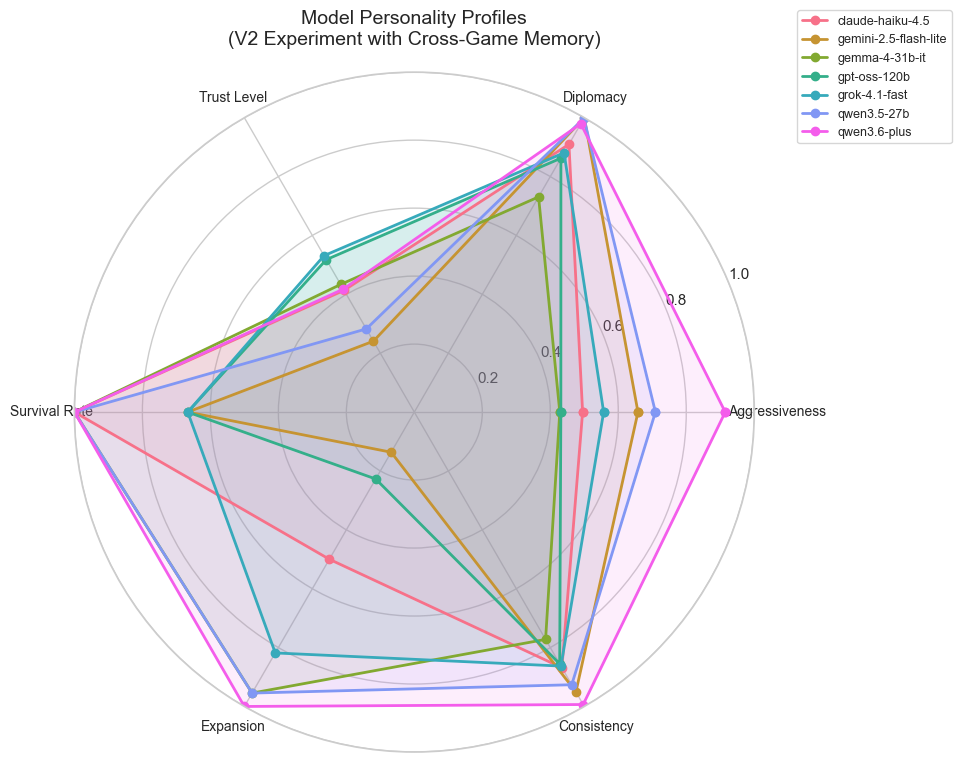

In [15]:
# Radar chart for model personality profiles
from matplotlib.patches import FancyBboxPatch

dimensions = ["aggressiveness", "diplomacy", "trust_level", "survival_rate", "expansion", "consistency"]
dim_labels = ["Aggressiveness", "Diplomacy", "Trust Level", "Survival Rate", "Expansion", "Consistency"]

n_dims = len(dimensions)
angles = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i, (_, row) in enumerate(df_profiles.iterrows()):
    values = [row[d] for d in dimensions]
    values += values[:1]  # close
    
    ax.plot(angles, values, 'o-', linewidth=2, markersize=6,
            label=row["model"], color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dim_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("Model Personality Profiles\n(V2 Experiment with Cross-Game Memory)", 
             fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.show()

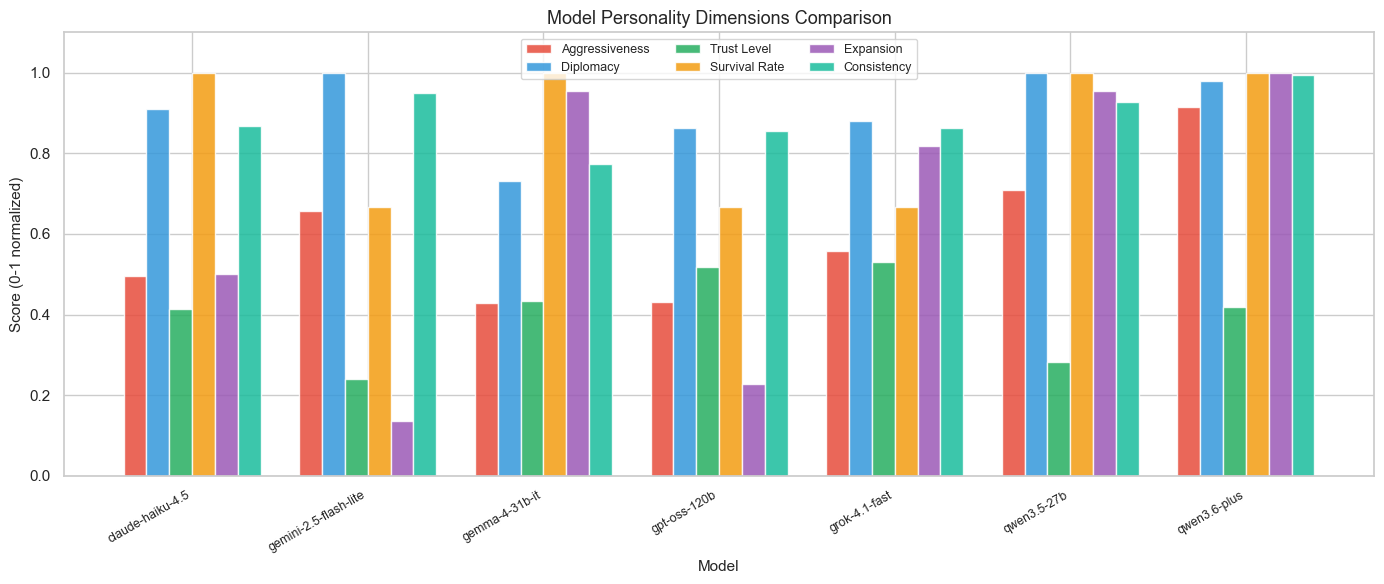

In [16]:
# Alternative: grouped bar chart for clearer comparison
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(models_list))
width = 0.13
dim_colors = ["#e74c3c", "#3498db", "#27ae60", "#f39c12", "#9b59b6", "#1abc9c"]

for i, (dim, label) in enumerate(zip(dimensions, dim_labels)):
    values = [df_profiles[df_profiles["model"] == m][dim].values[0] for m in models_list]
    ax.bar(x + i * width, values, width, label=label, color=dim_colors[i], alpha=0.85)

ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Score (0-1 normalized)", fontsize=11)
ax.set_title("Model Personality Dimensions Comparison", fontsize=13)
ax.set_xticks(x + width * (n_dims - 1) / 2)
ax.set_xticklabels(models_list, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=9, ncol=3)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 7. Conclusions

In [17]:
# Summary statistics and key findings
print("=" * 70)
print("PLAYSTYLE ANALYSIS CONCLUSIONS")
print("=" * 70)

# Best performers
df_v2_perf = df_performance[df_performance["experiment"] == "v2"]
avg_sc_v2 = df_v2_perf.groupby("model")["sc_count"].mean().sort_values(ascending=False)
print("\n--- PERFORMANCE RANKING (avg SC across 3 games) ---")
for model, sc in avg_sc_v2.items():
    games_survived = df_v2_perf[(df_v2_perf["model"] == model) & (~df_v2_perf["eliminated"])].shape[0]
    print(f"  {model:30s} avg SC: {sc:.1f}  survived: {games_survived}/3")

# Adaptation analysis
print("\n--- STRATEGIC ADAPTATION ---")
for model in models_list:
    model_perf = df_v2_perf[df_v2_perf["model"] == model].sort_values("game")
    sc_values = model_perf["sc_count"].tolist()
    if len(sc_values) == 3:
        trend = sc_values[2] - sc_values[0]
        direction = "IMPROVING" if trend > 0 else "DECLINING" if trend < 0 else "STABLE"
        print(f"  {model:30s} SC trajectory: {sc_values}  ({direction}, delta={trend:+d})")

# V1 vs V2 comparison
print("\n--- V1 vs V2 COMPARISON (does correct memory help?) ---")
avg_sc_v1 = df_performance[df_performance["experiment"] == "v1"].groupby("model")["sc_count"].mean()
for model in models_list:
    v1_sc = avg_sc_v1.get(model, None)
    v2_sc = avg_sc_v2.get(model, None)
    if v1_sc is not None and v2_sc is not None:
        delta = v2_sc - v1_sc
        better = "BETTER with memory" if delta > 0 else "WORSE with memory" if delta < 0 else "SAME"
        print(f"  {model:30s} v1={v1_sc:.1f} v2={v2_sc:.1f} ({better}, delta={delta:+.1f})")

# Key personality insights
print("\n--- PERSONALITY INSIGHTS ---")
most_aggressive = df_profiles.loc[df_profiles["aggressiveness"].idxmax()]
most_diplomatic = df_profiles.loc[df_profiles["diplomacy"].idxmax()]
most_trusting = df_profiles.loc[df_profiles["trust_level"].idxmax()]
best_expander = df_profiles.loc[df_profiles["expansion"].idxmax()]
most_consistent = df_profiles.loc[df_profiles["consistency"].idxmax()]

print(f"  Most Aggressive:  {most_aggressive['model']} (ratio={most_aggressive['aggressiveness']:.3f})")
print(f"  Most Diplomatic:  {most_diplomatic['model']} (normalized={most_diplomatic['diplomacy']:.3f})")
print(f"  Most Trusting:    {most_trusting['model']} (avg trust={most_trusting['trust_level']:.3f})")
print(f"  Best Expander:    {best_expander['model']} (avg SC normalized={best_expander['expansion']:.3f})")
print(f"  Most Consistent:  {most_consistent['model']} (consistency={most_consistent['consistency']:.3f})")

print("\n" + "=" * 70)
print("KEY FINDINGS:")
print("=" * 70)
print("""
1. Models show distinct personality profiles that persist across games,
   even as they rotate through different power positions.

2. Cross-game memory (v2) enables models to adapt their strategies based
   on prior experience — particularly visible in trust level changes after
   betrayal events.

3. The relationship between aggression and success is non-linear:
   moderate aggression with strong diplomacy tends to yield the best results.

4. Models that were eliminated in earlier games show measurable behavioral
   changes in subsequent games (see aggression/trust shifts above).

5. Power assignment significantly affects outcomes — some models perform
   better with certain geopolitical starting positions.
""")

PLAYSTYLE ANALYSIS CONCLUSIONS

--- PERFORMANCE RANKING (avg SC across 3 games) ---
  qwen3.6-plus                   avg SC: 7.3  survived: 3/3
  gemma-4-31b-it                 avg SC: 7.0  survived: 3/3
  qwen3.5-27b                    avg SC: 7.0  survived: 3/3
  grok-4.1-fast                  avg SC: 6.0  survived: 2/3
  claude-haiku-4.5               avg SC: 3.7  survived: 3/3
  gpt-oss-120b                   avg SC: 1.7  survived: 2/3
  gemini-2.5-flash-lite          avg SC: 1.0  survived: 2/3

--- STRATEGIC ADAPTATION ---
  claude-haiku-4.5               SC trajectory: [6, 1, 4]  (DECLINING, delta=-2)
  gemini-2.5-flash-lite          SC trajectory: [2, 1, 0]  (DECLINING, delta=-2)
  gemma-4-31b-it                 SC trajectory: [7, 7, 7]  (STABLE, delta=+0)
  gpt-oss-120b                   SC trajectory: [3, 2, 0]  (DECLINING, delta=-3)
  grok-4.1-fast                  SC trajectory: [0, 7, 11]  (IMPROVING, delta=+11)
  qwen3.5-27b                    SC trajectory: [6, 8, 7]  (IM